In [25]:
import os
import torch
import pandas as pd
import scanpy as sc
from sklearn import metrics
import multiprocessing as mp
import anndata as ad
import numpy as np

import scanpy as sc
import ot
from sklearn.decomposition import PCA


from GraphST import GraphST 

In [26]:
import pathlib
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
os.environ["R_HOME"] = "/usr/lib/R"
os.environ["R_LIBS_USER"] = "/usr/lib/R/site-library"
# pulizia variabili che potrebbero forzare altro

os.environ["LD_LIBRARY_PATH"] = "/usr/lib/R/lib:" + os.environ.get("LD_LIBRARY_PATH", "")

# (pulizia)
os.environ.pop("R_ENVIRON", None)
os.environ.pop("R_ENVIRON_USER", None)

# verifica che i file chiave esistano
print("lapack.so esiste?", pathlib.Path("/usr/lib/R/modules/lapack.so").exists())
print("libR.so esiste?",    pathlib.Path("/usr/lib/R/lib/libR.so").exists())



lapack.so esiste? True
libR.so esiste? True


In [27]:
import rpy2.robjects as ro

print(ro.r("R.home()"))
print(ro.r(".libPaths()"))
print(ro.r("R.version.string"))
ro.r('find.package("mclust")')

[1] "/usr/lib/R"

[1] "/usr/lib/R/site-library"       "/usr/local/lib/R/site-library"
[3] "/usr/lib/R/library"           

[1] "R version 4.3.3 (2024-02-29)"



'/usr/lib/R/site-library/mclust'


In [4]:
n_clusters = 7 #sono 7 perchè su google ci sono 7 cluster?
dataset    = '151673' #id del dataset. non viene usato.

In [28]:
def load_data():
    h5ad_file       = '1.DLPFC/151673/scRNA.h5ad'
    expression_file = '1.DLPFC/151673/filtered_feature_bc_matrix.h5'
    oprefix         = 'DLPFC-151673'
    
    adata_gene_expression = sc.read_visium('1.DLPFC/151673', count_file='filtered_feature_bc_matrix.h5', load_images=True)
    adata_gene_expression.var_names_make_unique()
    
    return adata_gene_expression

In [6]:
adata = load_data()

/home/cero/Desktop/Uni/Tesi_Cerinelli/.venv-rpy2/lib/python3.8/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [49]:
import numpy as np
import pandas as pd
from sklearn import metrics
import scanpy as sc
import ot
from sklearn.decomposition import PCA

def mclust_R(adata, num_cluster, modelNames='EEE', used_obsm='emb_pca', random_seed=2020):
    
    np.random.seed(random_seed)
    import rpy2.robjects as robjects
    robjects.r.library("mclust")

    import rpy2.robjects.numpy2ri
    rpy2.robjects.numpy2ri.activate()
    r_random_seed = robjects.r['set.seed']
    r_random_seed(random_seed)
    rmclust = robjects.r['Mclust']
    
    res = rmclust(rpy2.robjects.numpy2ri.numpy2rpy(adata.obsm[used_obsm]), num_cluster, modelNames)
    mclust_res = np.array(res[-2])

    adata.obs['mclust'] = mclust_res
    adata.obs['mclust'] = adata.obs['mclust'].astype('int')
    adata.obs['mclust'] = adata.obs['mclust'].astype('category')
    return adata

def refine_label(adata, radius=50, key='label'):
    n_neigh = radius
    new_type = []
    old_type = adata.obs[key].values
    
    #calculate distance
    position = adata.obsm['spatial']
    distance = ot.dist(position, position, metric='euclidean')
           
    n_cell = distance.shape[0]
    
    for i in range(n_cell):
        vec  = distance[i, :]
        index = vec.argsort()
        neigh_type = []
        for j in range(1, n_neigh+1):
            neigh_type.append(old_type[index[j]])
        max_type = max(neigh_type, key=neigh_type.count)
        new_type.append(max_type)
        
    new_type = [str(i) for i in list(new_type)]    
    #adata.obs['label_refined'] = np.array(new_type)
    
    return new_type

def clustering(adata, n_clusters=7, radius=50, key='emb', method='mclust', start=0.1, end=3.0, increment=0.01, refinement=False):

    pca = PCA(n_components=16, random_state=42) 
    embedding = pca.fit_transform(adata.obsm['emb'].copy())
    adata.obsm['emb_pca'] = embedding
    
    if method == 'mclust':
       adata = mclust_R(adata, used_obsm='emb_pca', num_cluster=n_clusters)
       adata.obs['domain'] = adata.obs['mclust']

    if refinement:  
       new_type = refine_label(adata, radius, key='domain')
       adata.obs['domain'] = new_type 

def clustering_small_hub(adata, n_clusters=7, radius=50, key='emb', method='mclust', start=0.1, end=3.0, increment=0.01, refinement=False):

    pca = PCA(n_components=6, random_state=42) 
    embedding = pca.fit_transform(adata.obsm['emb'].copy())
    adata.obsm['emb_pca'] = embedding
    
    if method == 'mclust':
       adata = mclust_R(adata, used_obsm='emb_pca', num_cluster=n_clusters)
       adata.obs['domain'] = adata.obs['mclust']

    if refinement:  
       new_type = refine_label(adata, radius, key='domain')
       adata.obs['domain'] = new_type 


In [54]:
adata = ad.read_h5ad("processed_adata_cerinelli.h5ad")

In [55]:
os.environ['Renviron'] = "/usr/lib/R"
clustering(adata, n_clusters, refinement=True)

fitting ...
  |======================================================================| 100%


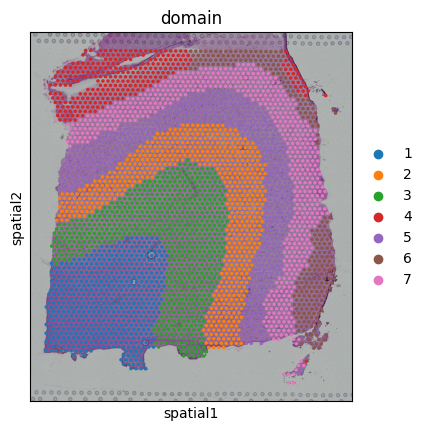

In [56]:
sc.pl.spatial(adata,
              img_key = "hires",
              color   = "domain",
              show=True)

In [34]:
original_gene_ids = np.load("transformed_gdata_gene_ids.npy")

geneIdsToSaveMainHub = [837,810,183,240,578,116,193,700,792,892,437,815,691,553,278,843]
geneIdsToSaveSmallHub = [194,703,597,731,859,399]

originalGeneIdsToSaveMainHub=[]
for i in geneIdsToSaveMainHub:
    originalGeneIdsToSaveMainHub.append(original_gene_ids[i])

print(originalGeneIdsToSaveMainHub)

originalGeneIdsToSaveSmallHub=[]
for i in geneIdsToSaveSmallHub:
    originalGeneIdsToSaveSmallHub.append(original_gene_ids[i])

print(originalGeneIdsToSaveSmallHub)



[28861, 27726, 6120, 8013, 19296, 4116, 6501, 23218, 26908, 31043, 14002, 28000, 22818, 18506, 9319, 29117]
[6546, 23243, 19815, 24099, 29638, 12869]


In [35]:
adata = load_data()

adata_main_hub  = adata[:, originalGeneIdsToSaveMainHub].copy() #Mi prendo solo i geni del mainHub ma tutti gli spot
adata_small_hub = adata[:, originalGeneIdsToSaveSmallHub].copy()#Mi prendo solo i geni del smallHub ma tutti gli spot

/home/cero/Desktop/Uni/Tesi_Cerinelli/.venv-rpy2/lib/python3.8/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [36]:
model = GraphST.GraphST(adata_main_hub, device=device)
adata_main_hub = model.train()

adata_main_hub.write_h5ad(filename="main_hub_close_adata")

/home/cero/Desktop/Uni/Tesi_Cerinelli/.venv-rpy2/lib/python3.8/site-packages/scanpy/preprocessing/_normalization.py:197: UserWarning: Some cells have zero counts
  warn(UserWarning('Some cells have zero counts'))


Begin to train ST data...


100%|██████████| 600/600 [04:12<00:00,  2.38it/s]


Optimization finished for ST data!


In [77]:
adata_main_hub = ad.read_h5ad("main_hub_close_adata")
#os.environ['Renviron'] = "/usr/lib/R"
clustering(adata_main_hub, 6, refinement=True)

fitting ...
  |======================================================================| 100%


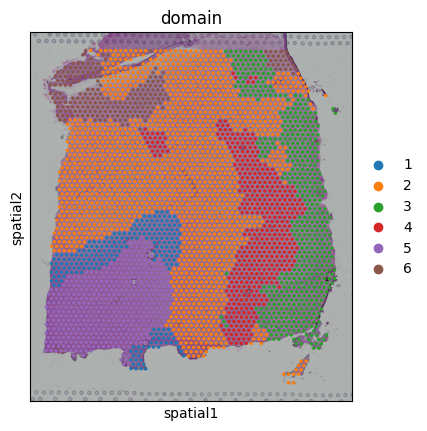

In [78]:
sc.pl.spatial(adata_main_hub,
              img_key = "hires",
              color   = "domain",
              show=True)

In [47]:

adata_small_hub2 = adata_small_hub.copy()

# normalizzazione minima come in preprocess()
sc.pp.normalize_total(adata_small_hub2, target_sum=1e4)
sc.pp.log1p(adata_small_hub2)
adata_small_hub2.raw = adata_small_hub2

# marca tutti i geni come HVG (subset piccolo)
adata_small_hub2.var['highly_variable'] = True

# ora GraphST non richiamerà hvgs
model = GraphST.GraphST(adata_small_hub2, device=device)
adata_small_hub2 = model.train()


# model = GraphST.GraphST(adata_small_hub, device=device)
# adata_small_hub = model.train()

# adata_small_hub.write_h5ad(filename="small_hub_close_adata")

/home/cero/Desktop/Uni/Tesi_Cerinelli/.venv-rpy2/lib/python3.8/site-packages/scanpy/preprocessing/_normalization.py:197: UserWarning: Some cells have zero counts
  warn(UserWarning('Some cells have zero counts'))


Begin to train ST data...


100%|██████████| 600/600 [05:08<00:00,  1.94it/s]


Optimization finished for ST data!


In [81]:
adata_small_hub2.write_h5ad(filename="small_hub2_close_adata")
adata_small_hub2 = ad.read_h5ad("small_hub2_close_adata")
#os.environ['Renviron'] = "/usr/local/lib/R"
clustering_small_hub(adata_small_hub2, 4, refinement=True)

fitting ...
  |======================================================================| 100%


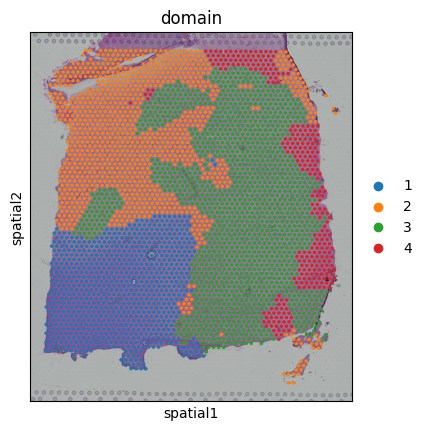

In [82]:
sc.pl.spatial(adata_small_hub2,
              img_key = "hires",
              color   = "domain",
              show=True)

In [52]:
from sklearn.metrics import silhouette_score, silhouette_samples
import numpy as np
import pandas as pd

def compute_silhouette(adata, used_obsm='emb_pca', labels_key='domain', metric='euclidean'):
    # 1) prendi embedding e etichette
    if used_obsm not in adata.obsm_keys():
        raise KeyError(f"{used_obsm} non presente in adata.obsm")
    if labels_key not in adata.obs.columns:
        raise KeyError(f"{labels_key} non presente in adata.obs")
        
    X = np.asarray(adata.obsm[used_obsm])
    # rendi le etichette codici numerici stabili (0..K-1), preservando la mappatura
    cats = adata.obs[labels_key].astype('category')
    y    = cats.cat.codes.to_numpy()  # -1 se NaN (qui non dovresti averne)

    # 2) check cluster
    uniq = np.unique(y[y >= 0])
    if uniq.size < 2:
        raise ValueError("Silhouette non definita: serve almeno 2 cluster.")

    # (opzionale) se ci sono cluster singoletto, silhouette_samples li definisce ma possono dare valori limite;
    # puoi decidere di proseguire comunque.

    # 3) calcolo silhouette
    s_overall  = silhouette_score(X, y, metric=metric)
    s_samples  = silhouette_samples(X, y, metric=metric)
    adata.obs['silhouette'] = s_samples

    # 4) media per cluster, con etichette originali
    code2label = dict(enumerate(cats.cat.categories))
    df = pd.DataFrame({'code': y, 'sil': s_samples})
    per_cluster = (
        df.groupby('code')['sil']
          .mean()
          .rename(index=code2label)   # rimappa ai nomi/etichette originali
          .sort_values(ascending=False)
    )

    return float(s_overall), per_cluster

In [58]:

overall, per_cluster = compute_silhouette(adata_main_hub,
                                          used_obsm='emb_pca',
                                          labels_key='domain',
                                          metric='euclidean')

print("Silhouette overall:", overall)

Silhouette overall: 0.015119604766368866


In [62]:

overall, per_cluster = compute_silhouette(adata_small_hub2,
                                          used_obsm='emb_pca',
                                          labels_key='domain',
                                          metric='euclidean')

print("Silhouette overall:", overall)

Silhouette overall: 0.20100697875022888
